# Case study: investment committee review of a two-sleeve systematic fund

**Situation.** A quantitative team asks the investment committee of an asset manager to launch a systematic fund with EUR 100
million of capital (illustrative) combining two strategies researched in this repository:

| sleeve | strategy | research notebook |
| --- | --- | --- |
| Trend | 12-month time-series momentum on four currencies against the euro and three energy spot prices (plus the 10-year Treasury when FRED is reachable) | [`multi_asset_time_series_momentum.ipynb`](../trend_following/multi_asset_time_series_momentum.ipynb) |
| Relative value | WTI-Brent statistical arbitrage with a Kalman-filter hedge ratio, yearly walk-forward re-estimation and an adaptive z-score | [`wti_brent_kalman_pairs.ipynb`](../statistical_arbitrage/wti_brent_kalman_pairs.ipynb) |

**Task of the risk function.** Build the portfolio as it would be run (sizing, risk budgets, volatility cap, drawdown control),
measure its performance and risk on 2013-2025, stress it, test the statistical evidence against the number of configurations tried
during research, and issue a **go / pilot / no-go recommendation** against criteria fixed in advance, with the limits that would
govern the live fund. The notebook ends with a one-page memo generated from the numbers.

**Portfolio construction.**

1. Each sleeve has a 10% annualised volatility budget on the fund's capital. The trend sleeve scales its positions with the engine's
   portfolio volatility target (one-day execution lag, costs on all turnover). The relative-value sleeve sizes the spread position so
   that an open position has 10% volatility, using the EWMA volatility of the daily P&L of one unit of spread (information up to $t-1$).
2. The fund return is the sum of the two sleeves; when its estimated volatility exceeds 10%, exposure is scaled down (cap, never up).
3. Drawdown control: exposure is halved when the fund's drawdown from its 12-month peak exceeds 10% and quartered beyond 20%,
   restored as it recovers. Measuring the drawdown from the all-time peak is shown as a sensitivity: after a deep loss it can keep
   the fund de-risked for years, which makes recovery almost impossible.

**Assumptions and caveats.** Spot prices stand in for futures and forwards (no carry, roll yield or funding costs); transaction costs are
5 basis points of turnover for the trend sleeve and USD 0.02 per barrel per leg for the pairs; the rescaling of the pairs position
and the fund-level cap are applied to returns and their extra trading costs are not charged; returns are expressed in the currency
of each instrument and treated as fully hedged into euro. The relative-value variant was chosen among four after seeing 2010-2025:
its figures are not a clean out-of-sample test, which is why the deflated Sharpe ratio counts all research trials.

**Data.** Official ECB and EIA (FRED) series cached in `data/raw/`; `BACKTEST_ENGINE_DATA_MODE=synthetic` runs the notebook offline on
simulated data (not market data). **Requirements.** `python -m pip install -e scripts/backtest_engine`.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repository root (used for data and output paths).
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "backtest_engine").is_dir())
try:
    import backtest_engine
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "backtest_engine"))
    import backtest_engine
from backtest_engine import data, metrics as mt, portfolio as pf, strategies as st, synthetic

core = backtest_engine.require_cpp()

DATA_MODE = os.environ.get("BACKTEST_ENGINE_DATA_MODE", "official")  # "official" (ECB, EIA, Federal Reserve) or "synthetic"
START, END = "1988-01-01", "2025-12-31"
FUND_START = "2010-01-01"        # first year of walk-forward signals for the relative-value sleeve
EVAL_START = "2013-01-01"        # evaluation window: after the momentum research sample (1999-2012)
AUM_EUR = 100e6                  # illustrative capital of the fund, EUR

# Trend sleeve: 12-month time-series momentum (Moskowitz, Ooi and Pedersen, 2012), the literature's standard horizon.
LOOKBACK, COM, ASSET_VOL, MAX_LEVERAGE, COST_TREND = 252, 60.0, 0.40, 5.0, 0.0005
# Relative-value sleeve: WTI-Brent Kalman pairs, walk-forward hyperparameters, adaptive z-score, textbook thresholds.
ENTRY, EXIT, STOP, COST_PAIRS, BURN_IN, Z_HALFLIFE = 2.0, 0.5, 4.0, 0.02, 60, 60
LAG = 1                          # every signal is executed one day after it is computed
SLEEVE_VOL = 0.10                # volatility budget of each sleeve on the fund's capital
FUND_VOL_CAP = 0.10              # the fund's exposure is reduced whenever its estimated volatility exceeds this cap
DD_LEVELS = ((0.10, 0.5), (0.20, 0.25))   # drawdown control: halve exposure beyond 10%, quarter it beyond 20%
DD_WINDOW = 252                  # drawdown measured from the 12-month peak, so that exposure is eventually restored
SEED = 20240517                  # stationary bootstrap
N_TRIALS_RESEARCH = {"momentum grid": 104, "momentum horizons and ensembles": 6, "pairs grid": 70, "pairs signal variants": 4}

# Decision criteria agreed before looking at the results (they are the committee's policy, not fitted values).
CRITERIA = {
    "Sharpe ratio 2013-2025": (">=", 0.50, "evidence"),
    "Bootstrap 95% lower bound of the Sharpe ratio": (">", 0.0, "evidence"),
    "Deflated Sharpe ratio (all research trials)": (">=", 0.95, "evidence"),
    "Maximum drawdown": ("<=", 0.20, "risk"),
    "1-day 99% historical VaR": ("<=", 0.02, "risk"),
    "10-day 97.5% historical ES": ("<=", 0.06, "risk"),
    "Worst drawdown in a stress window": ("<=", 0.15, "risk"),
    "Correlation between sleeves": ("<=", 0.50, "risk"),
}
OUTPUT_DIR = ROOT / "outputs" / "investment_committee"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
from backtest_engine.figstyle import MUTED, NEGATIVE, SERIES, notebook_style, ordinal_colors
notebook_style()   # validated palette, recessive grid, constrained layout (see figstyle.py)
print(f"backtest_engine {backtest_engine.__version__} | data mode: {DATA_MODE}")

backtest_engine 0.1.0 | data mode: official


## 1. Data

In [2]:
if DATA_MODE == "official":
    fx = data.load_ecb_fx_rates(("USD", "GBP", "JPY", "CHF"), start="1999-01-01", end=END)
    energy = data.load_fred(["DCOILWTICO", "DCOILBRENTEU", "DHHNGSP"], start=START, end=END)
    blocks = [(1.0 / fx).rename(columns=lambda c: f"{c} (in EUR)"),
              energy.loc["1999-01-01":].where(energy > 0).rename(columns={"DCOILWTICO": "WTI", "DCOILBRENTEU": "Brent",
                                                                          "DHHNGSP": "Henry Hub"})]
    sources = [fx.attrs["source"], energy.attrs["source"]]
    try:
        treasury = data.load_fred(["DGS10"], start="1999-01-01", end=END)
        blocks.append(data.treasury_total_return_index(treasury["DGS10"]).rename("UST 10Y TR"))
        sources.append(treasury.attrs["source"])
    except OSError as err:  # FRED unreachable and no cached copy
        print(f"WARNING: DGS10 not available ({err}); the trend sleeve runs without the Treasury.")
    universe = pd.concat(blocks, axis=1, sort=True).ffill(limit=5)
    pair = energy[["DCOILWTICO", "DCOILBRENTEU"]].dropna().rename(columns={"DCOILWTICO": "WTI", "DCOILBRENTEU": "Brent"})
else:
    universe = synthetic.trending_prices(n=7000, n_assets=8, start="1999-01-04")
    pair = synthetic.cointegrated_pair(n=9500, start="1988-01-04").rename(columns={"y": "WTI", "x": "Brent"}).loc[START:END]
    sources = [universe.attrs["source"], pair.attrs["source"]]
print("Sources:", *sources, sep="\n  ")
print(f"Trend universe: {universe.shape[1]} instruments, {universe.index[0]:%Y-%m-%d} to {universe.index[-1]:%Y-%m-%d}; "
      f"pair: {len(pair):,} days from {pair.index[0]:%Y-%m-%d}")

Sources:
  European Central Bank, euro foreign exchange reference rates (https://www.ecb.europa.eu/stats/eurofxref/eurofxref-hist.zip)
  WTI crude oil spot price, Cushing, USD per barrel (EIA via FRED); Brent crude oil spot price, Europe, USD per barrel (EIA via FRED); Henry Hub natural gas spot price, USD per MMBtu (EIA via FRED)
  10-year Treasury constant-maturity yield, percent (Federal Reserve H.15 via FRED)
Trend universe: 8 instruments, 1999-01-04 to 2025-12-31; pair: 8,075 days from 1988-01-04


## 2. The two sleeves

In [3]:
# Trend: 12-month momentum; the engine's portfolio volatility target applies the sleeve budget with a one-day lag and full costs.
trend = st.tsmom_ensemble(universe, [LOOKBACK], COM, ASSET_VOL, MAX_LEVERAGE, COST_TREND, LAG,
                          portfolio_target_vol=SLEEVE_VOL, portfolio_com=60.0, max_scale=3.0)

# Relative value: hyperparameters re-estimated every January on all earlier data, adaptive z-score, textbook thresholds.
y, x = pair["WTI"], pair["Brent"]
signal, yearly_params = st.walk_forward_kalman(y, x, first_year=int(FUND_START[:4]), burn_in=BURN_IN)
signal = signal.assign(z=st.adaptive_zscore(signal, halflife=Z_HALFLIFE))
pairs = st.pairs_backtest(y, x, signal, ENTRY, EXIT, STOP, COST_PAIRS, LAG, start=BURN_IN)
unit_risk = y.diff() - signal["beta_filt"].shift(1) * x.diff()    # daily P&L of one unit of spread, always open
relative_value = pf.volatility_targeted(pairs["pnl"], SLEEVE_VOL, halflife=60, risk=unit_risk)

sleeves = pd.DataFrame({"trend": trend["returns"], "relative value": relative_value}).fillna(0.0).loc[FUND_START:END]
invested = (pairs["units_y"] != 0).reindex(sleeves.index, fill_value=False)
print(f"Relative-value sleeve invested {invested.loc[EVAL_START:].mean():.0%} of the days in 2013-2025; "
      f"realised volatility while invested {sleeves.loc[EVAL_START:, 'relative value'][invested.loc[EVAL_START:]].std() * np.sqrt(252):.1%}")

Relative-value sleeve invested 5% of the days in 2013-2025; realised volatility while invested 8.4%


## 3. The fund: volatility cap and drawdown control

,annual return,annual volatility,Sharpe,Sortino,max drawdown,Calmar,worst month,positive months,skewness
trend,0.0324,0.1058,0.3060,0.4644,0.3635,0.0891,-0.0894,0.4808,1.8496
relative value,0.0064,0.0303,0.2122,0.3249,0.1452,0.0443,-0.0396,0.2692,1.4555
fund (vol cap),0.0349,0.1022,0.3410,0.5172,0.4116,0.0847,-0.0997,0.5192,1.8358
fund (vol cap + drawdown control),0.0471,0.0940,0.5015,0.7833,0.2928,0.1610,-0.0585,0.5192,2.4190


Correlation of daily sleeve returns: -0.01 (all days), +0.05 (days with a pairs position)
Days with reduced exposure because of drawdown control: 23%
Sensitivity, drawdown from the all-time peak: Sharpe 0.43, maximum drawdown 24.0%, reduced exposure on 71% of the days


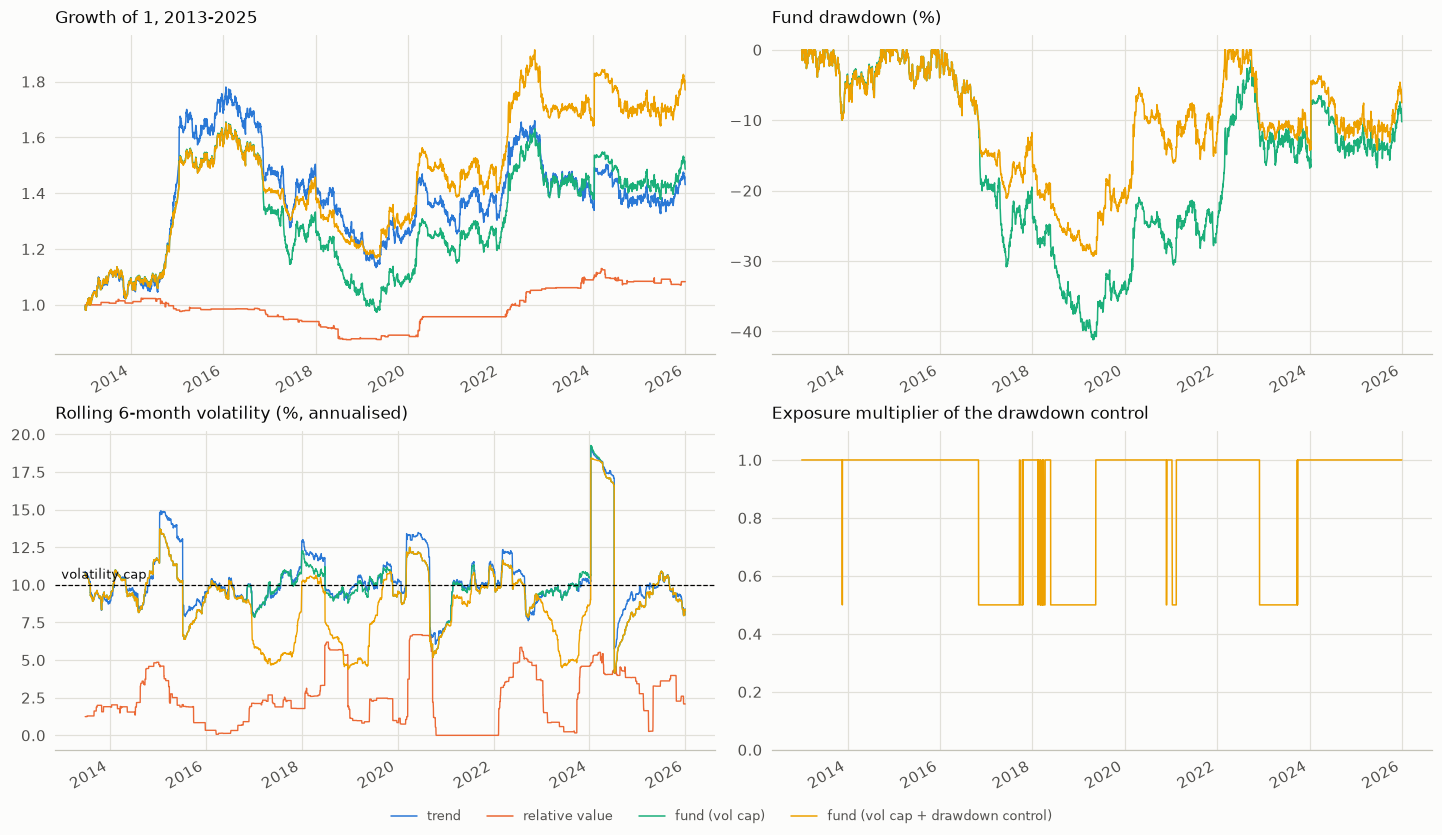

In [4]:
raw = sleeves.sum(axis=1)
capped = pf.volatility_targeted(raw, FUND_VOL_CAP, halflife=60, max_scale=1.0)
controlled = pf.drawdown_control(capped.loc[EVAL_START:], levels=DD_LEVELS, window=DD_WINDOW)
all_time = pf.drawdown_control(capped.loc[EVAL_START:], levels=DD_LEVELS)

ev = pd.DataFrame({"trend": sleeves.loc[EVAL_START:, "trend"], "relative value": sleeves.loc[EVAL_START:, "relative value"],
                   "fund (vol cap)": capped.loc[EVAL_START:], "fund (vol cap + drawdown control)": controlled["returns"]})

def summary(r):
    s = mt.performance_summary(r)
    monthly = (1 + r).resample("ME").prod() - 1
    return {"annual return": s["annual mean"], "annual volatility": s["annual volatility"], "Sharpe": s["Sharpe"],
            "Sortino": s["Sortino"], "max drawdown": s["max drawdown"], "Calmar": s["Calmar"],
            "worst month": monthly.min(), "positive months": (monthly > 0).mean(), "skewness": s["skewness"]}

perf = pd.DataFrame({k: summary(v) for k, v in ev.items()}).T
display(perf)
corr = ev[["trend", "relative value"]].corr().iloc[0, 1]
corr_invested = ev.loc[invested.loc[EVAL_START:], ["trend", "relative value"]].corr().iloc[0, 1]
print(f"Correlation of daily sleeve returns: {corr:+.2f} (all days), {corr_invested:+.2f} (days with a pairs position)")
print(f"Days with reduced exposure because of drawdown control: {(controlled['multiplier'] < 1).mean():.0%}")
s_all = summary(all_time["returns"])
print(f"Sensitivity, drawdown from the all-time peak: Sharpe {s_all['Sharpe']:.2f}, maximum drawdown {s_all['max drawdown']:.1%}, "
      f"reduced exposure on {(all_time['multiplier'] < 1).mean():.0%} of the days")

# One colour per series in every panel, one shared legend below the grid.
colors = dict(zip(ev.columns, SERIES))
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
(1 + ev).cumprod().plot(ax=axes[0, 0], lw=1.0, color=colors, legend=False)
axes[0, 0].set(title="Growth of 1, 2013-2025", xlabel="")
wealth = (1 + ev[["fund (vol cap)", "fund (vol cap + drawdown control)"]]).cumprod()
(100 * (wealth / wealth.cummax() - 1)).plot(ax=axes[0, 1], lw=1.0, color=colors, legend=False)
axes[0, 1].set(title="Fund drawdown (%)", xlabel="")
(100 * ev.rolling(126).std() * np.sqrt(252)).plot(ax=axes[1, 0], lw=0.9, color=colors, legend=False)
axes[1, 0].axhline(100 * FUND_VOL_CAP, color="k", ls="--", lw=0.8)
axes[1, 0].annotate("volatility cap", (axes[1, 0].get_xlim()[0], 100 * FUND_VOL_CAP), xytext=(4, 4),
                    textcoords="offset points", fontsize=8.5)
axes[1, 0].set(title="Rolling 6-month volatility (%, annualised)", xlabel="")
controlled["multiplier"].plot(ax=axes[1, 1], color=colors["fund (vol cap + drawdown control)"], lw=1.0)
axes[1, 1].set(title="Exposure multiplier of the drawdown control", ylim=(0, 1.1), xlabel="")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=len(labels))
fig.savefig(OUTPUT_DIR / "fund_performance.png", dpi=150)
fund = ev["fund (vol cap + drawdown control)"]

## 4. Market risk: VaR, expected shortfall and VaR backtest

Historical figures use overlapping compounded 10-day returns; normal figures use the sample mean and standard deviation. The 97.5%
expected shortfall is the metric of the Basel market-risk framework (FRTB). The VaR backtest compares each day's return with the
99% historical VaR forecast from the previous 250 days and classifies each calendar year with the Basel traffic light
(green: 0-4 exceptions, yellow: 5-9, red: 10 or more).

In [5]:
rows = {}
for level, horizon in ((0.99, 1), (0.975, 1), (0.99, 10), (0.975, 10)):
    res = pf.var_es(fund, level=level, horizon=horizon)
    rows[f"{level:.1%}, {horizon} day(s)"] = {k: v for k, v in res.items() if k != "observations"}
risk = pd.DataFrame(rows).T
display((risk * 100).round(2).rename(columns=lambda c: f"{c} (% of capital)"))
display((risk * AUM_EUR / 1e6).round(2).rename(columns=lambda c: f"{c} (EUR million)"))

var_forecast = pf.rolling_historical_var(pd.concat([capped.loc[:EVAL_START].iloc[:-1], fund]), level=0.99, window=250).loc[EVAL_START:]
exceptions = fund < -var_forecast
yearly = exceptions.groupby(exceptions.index.year).agg(["sum", "size"]).rename(columns={"sum": "exceptions", "size": "days"})
yearly["zone"] = [pf.basel_traffic_light(int(k * 250 / max(n, 1))) for k, n in zip(yearly["exceptions"], yearly["days"])]
display(yearly.T)
print(f"Exception rate {exceptions.mean():.2%} against 1.00% expected")

,VaR historical (% of capital),ES historical (% of capital),VaR normal (% of capital),ES normal (% of capital)
"99.0%, 1 day(s)",1.4500,1.9600,1.3600,1.5600
"97.5%, 1 day(s)",1.0900,1.5200,1.1400,1.3700
"99.0%, 10 day(s)",4.2200,5.0800,4.1700,4.8000
"97.5%, 10 day(s)",3.2400,4.2500,3.4800,4.1900


,VaR historical (EUR million),ES historical (EUR million),VaR normal (EUR million),ES normal (EUR million)
"99.0%, 1 day(s)",1.4500,1.9600,1.3600,1.5600
"97.5%, 1 day(s)",1.0900,1.5200,1.1400,1.3700
"99.0%, 10 day(s)",4.2200,5.0800,4.1700,4.8000
"97.5%, 10 day(s)",3.2400,4.2500,3.4800,4.1900


,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
exceptions,6,1,6,3,4,3,8,3,7,3,4,0,5
days,258,258,260,261,259,258,258,259,260,258,259,259,258
zone,yellow,green,yellow,green,green,green,yellow,green,yellow,green,green,green,green


Exception rate 1.58% against 1.00% expected


## 5. Stress tests

Historical windows within the evaluation period, chosen for their relevance to the fund's instruments, plus a hypothetical scenario in
which both sleeves suffer their worst calendar month at the same time (a breakdown of diversification).

In [6]:
windows = {
    "oil price collapse (Jun 2014 - Jan 2016)": ("2014-06-01", "2016-01-31"),
    "SNB removes the EUR/CHF floor (Jan 2015)": ("2015-01-12", "2015-01-30"),
    "Brexit referendum (Jun - Jul 2016)": ("2016-06-20", "2016-07-15"),
    "COVID-19 and negative WTI (Feb - May 2020)": ("2020-02-19", "2020-05-29"),
    "energy crisis and rate shock (2022)": ("2022-02-24", "2022-10-31"),
    "Henry Hub cold snap (Jan 2024)": ("2024-01-02", "2024-01-31"),
}
stress = pf.stress_table(ev, windows)
display((stress["return"].unstack().loc[list(windows), list(ev.columns)] * 100).round(1)
        .rename_axis(columns="return in the window (%)"))
monthly = (1 + ev[["trend", "relative value"]]).resample("ME").prod() - 1
joint = monthly.min().sum()
worst_hist = stress.xs("fund (vol cap + drawdown control)", level="strategy")["max drawdown"].max()
print(f"Hypothetical: both sleeves lose their worst month together: {joint:.1%} of capital "
      f"(EUR {-joint * AUM_EUR / 1e6:.1f} million) before the volatility cap and drawdown control")
print(f"Worst drawdown of the fund inside a historical stress window: {worst_hist:.1%}")

return in the window (%),trend,relative value,fund (vol cap),fund (vol cap + drawdown control)
window,,,,
oil price collapse (Jun 2014 - Jan 2016),63.6000,-3.7000,49.8000,49.8000
SNB removes the EUR/CHF floor (Jan 2015),11.6000,-0.5000,8.4000,8.4000
Brexit referendum (Jun - Jul 2016),1.0000,-0.2000,0.7000,0.7000
COVID-19 and negative WTI (Feb - May 2020),7.6000,8.0000,13.0000,13.0000
energy crisis and rate shock (2022),6.8000,7.4000,12.6000,12.6000
Henry Hub cold snap (Jan 2024),8.5000,1.7000,9.9000,9.9000


Hypothetical: both sleeves lose their worst month together: -12.9% of capital (EUR 12.9 million) before the volatility cap and drawdown control
Worst drawdown of the fund inside a historical stress window: 6.1%


## 6. Statistical evidence

The fund's Sharpe ratio is tested three ways: a stationary-bootstrap confidence interval (mean block of 20 days), the probabilistic
Sharpe ratio against zero, and the deflated Sharpe ratio, whose benchmark is the maximum Sharpe ratio expected by chance from all
the configurations tried during research. The dispersion of trial Sharpe ratios is estimated from the in-sample results of the two
research grids, recomputed here with the C++ engine.

In [7]:
grid_trend, _ = st.tsmom_grid(universe, list(range(10, 261, 10)), [20.0, 40.0, 60.0, 90.0], ASSET_VOL, MAX_LEVERAGE, COST_TREND, LAG)
grid_trend = grid_trend.loc[:"2012-12-31"].iloc[300:]
mle = st.fit_kalman_mle(y.loc[:"2009-12-31"], x.loc[:"2009-12-31"], burn_in=BURN_IN)
grid_pairs, _ = st.pairs_grid(y, x, [1e-6, 1e-5, 1e-4, 1e-3, mle["delta"]], mle["obs_var"], [1.0, 1.5, 2.0, 2.5, 3.0],
                              [0.0, 0.5, 1.0], stop=STOP, cost_per_unit=COST_PAIRS, lag=LAG, start=BURN_IN)
grid_pairs = grid_pairs.loc[:"2009-12-31"].iloc[BURN_IN:]
trial_sharpes = np.r_[grid_trend.apply(lambda c: c.mean() / c.std(ddof=1)).to_numpy(),
                      grid_pairs.apply(lambda c: c.mean() / c.std(ddof=1)).to_numpy()]
n_trials = sum(N_TRIALS_RESEARCH.values())
benchmark = mt.expected_max_sharpe(np.nanvar(trial_sharpes, ddof=1), n_trials)
dsr = mt.probabilistic_sharpe_ratio(fund, benchmark)
psr = mt.probabilistic_sharpe_ratio(fund)
boot = mt.bootstrap_sharpe(fund.to_numpy(), mean_block=20, n_boot=10_000, seed=SEED)
lo, hi = np.percentile(boot, [2.5, 97.5])
sharpe = mt.sharpe_ratio(fund)
evidence = pd.Series({"Sharpe ratio 2013-2025": sharpe, "bootstrap 2.5%": lo, "bootstrap 97.5%": hi,
                      "PSR against 0": psr, f"expected max Sharpe of {n_trials} trials (annualised)": benchmark * np.sqrt(252),
                      "deflated Sharpe ratio": dsr}, name="value")
display(evidence.to_frame())
years_needed = ((1.96 / sharpe) ** 2) if sharpe > 0 else np.inf
print(f"Years of data needed for a Sharpe ratio of {sharpe:.2f} to be significant at 5% (normal returns): {years_needed:.0f}")

,value
Sharpe ratio 2013-2025,0.5015
bootstrap 2.5%,-0.0944
bootstrap 97.5%,1.0729
PSR against 0,0.9709
expected max Sharpe of 184 trials (annualised),0.6358
deflated Sharpe ratio,0.3060


Years of data needed for a Sharpe ratio of 0.50 to be significant at 5% (normal returns): 15


## 7. Decision and limits

In [8]:
values = {
    "Sharpe ratio 2013-2025": sharpe,
    "Bootstrap 95% lower bound of the Sharpe ratio": lo,
    "Deflated Sharpe ratio (all research trials)": dsr,
    "Maximum drawdown": perf.loc["fund (vol cap + drawdown control)", "max drawdown"],
    "1-day 99% historical VaR": risk.loc["99.0%, 1 day(s)", "VaR historical"],
    "10-day 97.5% historical ES": risk.loc["97.5%, 10 day(s)", "ES historical"],
    "Worst drawdown in a stress window": worst_hist,
    "Correlation between sleeves": corr,
}
ops = {">=": np.greater_equal, ">": np.greater, "<=": np.less_equal}
checks = pd.DataFrame([{"criterion": k, "type": kind, "threshold": f"{op} {thr:g}", "value": values[k],
                        "pass": bool(ops[op](values[k], thr))} for k, (op, thr, kind) in CRITERIA.items()]).set_index("criterion")
display(checks)
risk_ok = checks.loc[checks["type"] == "risk", "pass"].all()
evidence_ok = checks.loc[checks["type"] == "evidence", "pass"].all()
if risk_ok and evidence_ok:
    decision = "GO: launch with the full risk budget."
elif risk_ok and sharpe > 0:
    decision = ("PILOT: the risk profile is acceptable but the statistical evidence is insufficient. Launch with 25% of the risk "
                "budget (EUR 25 million equivalent) for 12 months under the limits below, then re-assess on live data.")
else:
    failed = "; ".join(checks.index[~checks["pass"]])
    decision = f"NO-GO: criteria not met ({failed}); return to research."
print("Recommendation:", decision)

,type,threshold,value,pass
criterion,,,,
Sharpe ratio 2013-2025,evidence,>= 0.5,0.5015,True
Bootstrap 95% lower bound of the Sharpe ratio,evidence,> 0,-0.0944,False
Deflated Sharpe ratio (all research trials),evidence,>= 0.95,0.3060,False
Maximum drawdown,risk,<= 0.2,0.2928,False
1-day 99% historical VaR,risk,<= 0.02,0.0145,True
10-day 97.5% historical ES,risk,<= 0.06,0.0425,True
Worst drawdown in a stress window,risk,<= 0.15,0.0607,True
Correlation between sleeves,risk,<= 0.5,-0.0074,True


Recommendation: NO-GO: criteria not met (Bootstrap 95% lower bound of the Sharpe ratio; Deflated Sharpe ratio (all research trials); Maximum drawdown); return to research.


**Limits for the live fund** (monitored daily by the risk function):

| limit | trigger | action |
| --- | --- | --- |
| Fund volatility | EWMA estimate above 10% | automatic scaling (built into the engine) |
| Drawdown | 10% / 20% from the 12-month peak; 25% from the all-time peak | exposure halved / quartered; fund suspended and escalated to the committee |
| 99% 1-day VaR backtest | 5 or more exceptions in 250 days (yellow zone) | model review; 10 or more (red zone): exposure halved until review |
| Relative-value sleeve | rolling two-year Engle-Granger test not rejecting at 10% for 3 consecutive months | sleeve suspended |
| Single instrument | gross weight above 50% of capital or a daily move above 5 standard deviations | position cap and incident report |
| Live performance | 12-month Sharpe ratio below the 5th percentile of the bootstrap distribution | strategy review |

In [9]:
top = perf.loc["fund (vol cap + drawdown control)"]
lines = [
    "# Investment committee memo: two-sleeve systematic fund",
    "",
    f"**Recommendation.** {decision}",
    "",
    "**Performance 2013-2025** (after trading costs, before fees): "
    f"annual return {top['annual return']:.1%}, volatility {top['annual volatility']:.1%}, Sharpe ratio {top['Sharpe']:.2f} "
    f"(95% bootstrap interval {lo:.2f} to {hi:.2f}), maximum drawdown {top['max drawdown']:.1%}, worst month {top['worst month']:.1%}.",
    "",
    f"**Diversification.** Correlation between the sleeves {corr:+.2f}; sleeve Sharpe ratios: trend {perf.loc['trend', 'Sharpe']:.2f}, "
    f"relative value {perf.loc['relative value', 'Sharpe']:.2f}.",
    "",
    f"**Risk** (EUR {AUM_EUR / 1e6:.0f} million of capital): 1-day 99% VaR EUR {values['1-day 99% historical VaR'] * AUM_EUR / 1e6:.1f} million; "
    f"10-day 97.5% ES EUR {values['10-day 97.5% historical ES'] * AUM_EUR / 1e6:.1f} million; worst historical stress-window drawdown "
    f"{worst_hist:.1%}; joint worst-month scenario {joint:.1%} before risk controls.",
    "",
    f"**Evidence.** Deflated Sharpe ratio {dsr:.2f} after {n_trials} research trials; the probability that the true Sharpe ratio is "
    f"positive is {psr:.0%}. About {years_needed:.0f} years of data would be needed for the observed Sharpe ratio to be significant.",
    "",
    "**Criteria.** " + "; ".join(f"{k}: {'pass' if v else 'fail'}" for k, v in checks["pass"].items()) + ".",
    "",
    "**Main caveats.** Spot prices stand in for futures (no carry or roll); costs of rescaling are not charged; the relative-value "
    "variant was chosen after seeing part of the evaluation period.",
]
memo = "\n".join(lines)
(OUTPUT_DIR / "memo.md").write_text(memo + "\n", encoding="utf-8")
print(memo)

# Investment committee memo: two-sleeve systematic fund

**Recommendation.** NO-GO: criteria not met (Bootstrap 95% lower bound of the Sharpe ratio; Deflated Sharpe ratio (all research trials); Maximum drawdown); return to research.

**Performance 2013-2025** (after trading costs, before fees): annual return 4.7%, volatility 9.4%, Sharpe ratio 0.50 (95% bootstrap interval -0.09 to 1.07), maximum drawdown 29.3%, worst month -5.8%.

**Diversification.** Correlation between the sleeves -0.01; sleeve Sharpe ratios: trend 0.31, relative value 0.21.

**Risk** (EUR 100 million of capital): 1-day 99% VaR EUR 1.5 million; 10-day 97.5% ES EUR 4.3 million; worst historical stress-window drawdown 6.1%; joint worst-month scenario -12.9% before risk controls.

**Evidence.** Deflated Sharpe ratio 0.31 after 184 research trials; the probability that the true Sharpe ratio is positive is 97%. About 15 years of data would be needed for the observed Sharpe ratio to be significant.

**Criteria.** Sharpe ra

## 8. How to read this case study

- The committee's criteria separate **risk** (can the fund be run within its limits?) from **evidence** (is there a durable edge?).
  A strategy can be safe to run and still unproven: the usual answer is a small pilot with pre-agreed limits and a review date,
  not a full allocation and not a rejection.
- Volatility budgets per sleeve and a fund-level cap make the risk of the fund stable and comparable across strategies; drawdown
  control limits the depth of losses at the cost of slower recoveries. Neither creates return.
- The deflated Sharpe ratio and the years-to-significance figure explain why a few years of a Sharpe ratio below 1 cannot
  distinguish skill from luck, especially after many configurations have been tried.
- Figures and the memo are saved in `outputs/investment_committee/`.

### References

- Bailey, D. H. and Lopez de Prado, M. (2014). The deflated Sharpe ratio. *Journal of Portfolio Management*, 40(5), 94-107.
- Basel Committee on Banking Supervision (1996). Supervisory framework for the use of "backtesting" in conjunction with the internal models approach to market risk capital requirements.
- Basel Committee on Banking Supervision (2019). Minimum capital requirements for market risk (FRTB).
- Harvey, C. R. and Liu, Y. (2015). Backtesting. *Journal of Portfolio Management*, 42(1), 13-28.
- Moreira, A. and Muir, T. (2017). Volatility-managed portfolios. *Journal of Finance*, 72(4), 1611-1644.
- Moskowitz, T. J., Ooi, Y. H. and Pedersen, L. H. (2012). Time series momentum. *Journal of Financial Economics*, 104(2), 228-250.
- Politis, D. N. and Romano, J. P. (1994). The stationary bootstrap. *Journal of the American Statistical Association*, 89(428), 1303-1313.